## Teleco Customer Churn

In [2]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 7.4 MB/s eta 0:00:00


In [4]:
!pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   -------------------------

In [6]:
! pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 5.3 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc

# Imbalance handling
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# Optimization
import optuna

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

## Load Data + Basic EDA

In [2]:
df = pd.read_csv('customer_churn.csv')

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

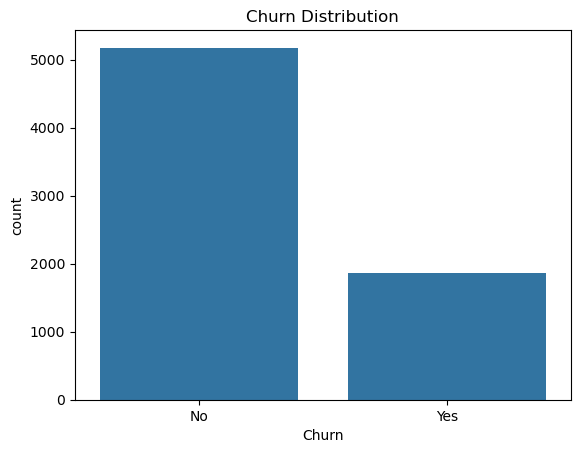

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
#Target Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn'].value_counts(normalize=True))

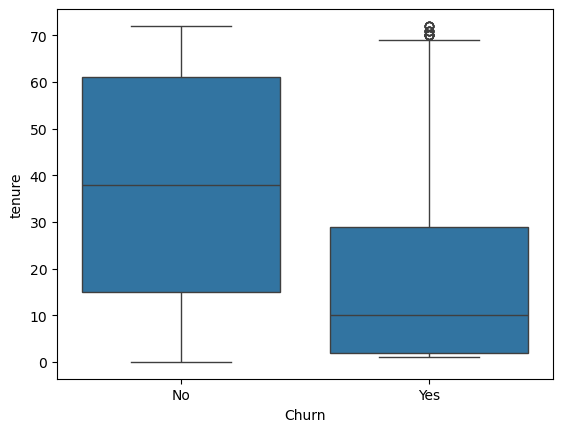

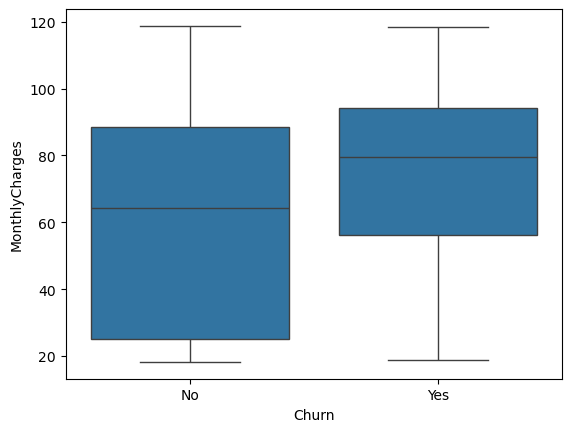

In [4]:
# Feature vs Churn

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

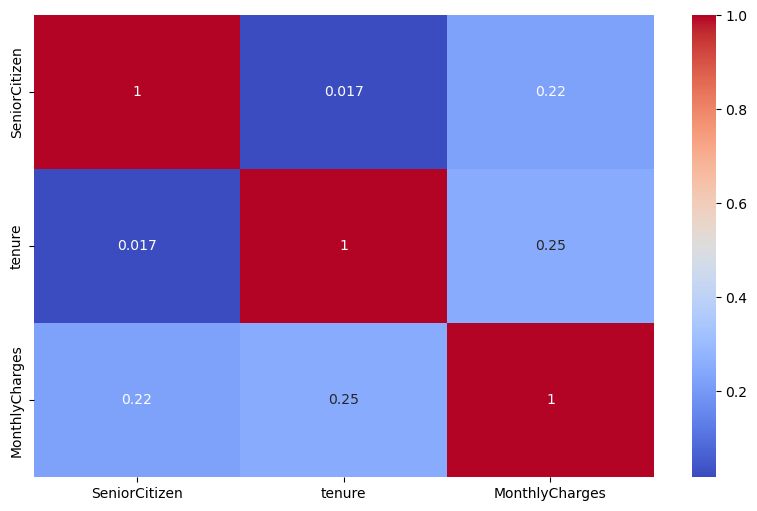

In [5]:
# Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Feature Engineering

In [6]:
# Tenure Buckets
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,60,100],
                           labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr'])

In [7]:
# Contract Value Ratio
df['value_ratio'] = df['MonthlyCharges'] / (df['tenure'] +1)

In [8]:
# Service Usage Score
services = ['PhoneService','InternetService','OnlineSecurity','StreamingTV']

df['service_score'] = df[services].apply(
    lambda x: sum([1 if i=='Yes' else 0 for i in x]), axis=1
)

## Encoding

In [9]:
# Convert target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Label encoding for categoricals
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

## Train-Test Split

In [10]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Handle Class Imbalance

In [19]:
!pip install --upgrade joblib

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.4.2
    Uninstalling joblib-1.4.2:
      Successfully uninstalled joblib-1.4.2


In [12]:
methods = {
    "SMOTE": SMOTE(),
    "ADASYN": ADASYN(),
    "Undersample": RandomUnderSampler(),
    "None": None
}

resampled_data = {}

for name, method in methods.items():
    if method:
        X_res, y_res = method.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train
        
    resampled_data[name] = (X_res, y_res)

## Train Models

In [13]:
models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "SVM": SVC(probability=True)
}

In [15]:
# Cross Validation

results = {}

for method, (X_res, y_res) in resampled_data.items():
    for name, model in models.items():
        score = cross_val_score(model, X_res, y_res,
                                cv=5, scoring='roc_auc').mean()
        
        results[(method, name)] = score

pd.Series(results).sort_values(ascending=False)

[LightGBM] [Info] Number of positive: 3311, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 6622, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3311, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 6622, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


SMOTE        LightGBM        0.939076
             XGBoost         0.936643
             RandomForest    0.933111
ADASYN       LightGBM        0.930317
             XGBoost         0.927893
             RandomForest    0.925686
SMOTE        Logistic        0.879299
ADASYN       Logistic        0.869399
None         LightGBM        0.836605
Undersample  Logistic        0.834393
None         Logistic        0.833632
Undersample  LightGBM        0.831745
             RandomForest    0.828712
None         RandomForest    0.828542
             XGBoost         0.824249
Undersample  XGBoost         0.818210
None         SVM             0.798650
ADASYN       SVM             0.664665
SMOTE        SVM             0.561581
Undersample  SVM             0.518480
dtype: float64

## Optuna Hyperparameter Tuning

In [16]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0)
    }
    
    model = XGBClassifier(**params, eval_metric='logloss')
    score = cross_val_score(model, X_train, y_train,
                            cv=3, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(study.best_params)

[I 2026-03-18 09:53:03,390] A new study created in memory with name: no-name-7456839f-376e-422c-b862-18aa48fca95b
[I 2026-03-18 09:53:07,620] Trial 0 finished with value: 0.8185823665913663 and parameters: {'n_estimators': 436, 'max_depth': 9, 'learning_rate': 0.1105270886310328, 'subsample': 0.9946713674540253}. Best is trial 0 with value: 0.8185823665913663.
[I 2026-03-18 09:53:09,792] Trial 1 finished with value: 0.8463598131925377 and parameters: {'n_estimators': 214, 'max_depth': 6, 'learning_rate': 0.010231589974532721, 'subsample': 0.558001395619161}. Best is trial 1 with value: 0.8463598131925377.
[I 2026-03-18 09:53:12,793] Trial 2 finished with value: 0.8110666819731273 and parameters: {'n_estimators': 248, 'max_depth': 9, 'learning_rate': 0.278011951701485, 'subsample': 0.8636134735128851}. Best is trial 1 with value: 0.8463598131925377.
[I 2026-03-18 09:53:14,270] Trial 3 finished with value: 0.8319499490570378 and parameters: {'n_estimators': 249, 'max_depth': 4, 'learning

{'n_estimators': 371, 'max_depth': 3, 'learning_rate': 0.019501048311106738, 'subsample': 0.7472374412990752}


## Evaluation Metrics

In [17]:
model = XGBClassifier(**study.best_params, eval_metric='logloss')
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

roc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("ROC-AUC:", roc)
print("F1:", f1)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.8448345346043554
F1: 0.5705614567526556
PR-AUC: 0.6562987573936397


## Custom Cost Metric

In [18]:
def cost_metric(y_true, y_pred):
    cost = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 0:
            cost += 500   # FN
        elif yt == 0 and yp == 1:
            cost += 50    # FP
    return cost

print("Cost:", cost_metric(y_test, y_pred))

Cost: 97850


## Profit Curve

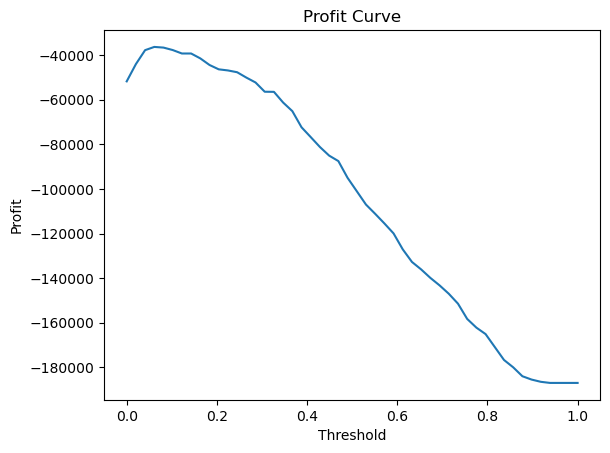

In [19]:
thresholds = np.linspace(0,1,50)
profits = []

for t in thresholds:
    preds = (y_prob > t).astype(int)
    profits.append(-cost_metric(y_test, preds))

plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit Curve")
plt.show()

## SHAP Explainability

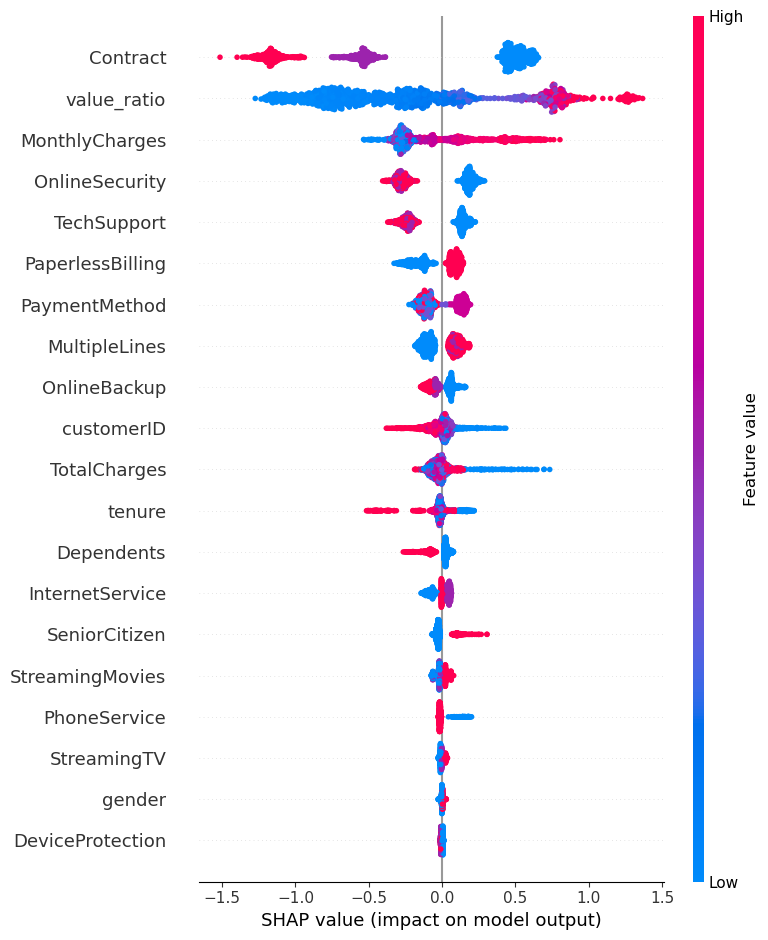

In [20]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

# Individual prediction
shap.plots.force(shap_values[0])

## Prediction Function

In [21]:
def predict_churn(input_data):
    input_df = pd.DataFrame([input_data])
    
    # Apply same preprocessing
    input_scaled = scaler.transform(input_df)
    
    prob = model.predict_proba(input_scaled)[0][1]
    
    # SHAP explanation
    shap_val = explainer(input_scaled)
    
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "impact": shap_val.values[0]
    }).sort_values(by="impact", key=abs, ascending=False)
    
    top3 = feature_importance.head(3)['feature'].tolist()
    
    # Business recommendation
    if prob > 0.7:
        action = "High risk → Offer discount / retention call"
    elif prob > 0.4:
        action = "Medium risk → Send engagement email"
    else:
        action = "Low risk → No action needed"
    
    return {
        "Churn Probability": prob,
        "Top Risk Factors": top3,
        "Recommended Action": action
    }

## Final Output Example

In [22]:
sample = X.iloc[0].to_dict()
predict_churn(sample)

{'Churn Probability': np.float32(0.33598006),
 'Top Risk Factors': ['value_ratio', 'Contract', 'MonthlyCharges'],
 'Recommended Action': 'Low risk → No action needed'}